In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 


In [2]:
df_final = pd.read_csv(r'..\data\processed\dados_consolidados_b3.csv')


In [3]:
# 1. Ordenar por Empresa e Ano para garantir que o cálculo temporal fique correto
df_final = df_final.sort_values(by=['TICKER', 'ANO']).reset_index(drop=True)

# 2. Calcular o Retorno Anual da ação (%) usando pct_change() agrupado por TICKER
df_final['RETORNO_ANO_%'] = df_final.groupby('TICKER')['COTACAO_FINAL_ANO'].pct_change() * 100

# Vamos ver como ficou (olhando as primeiras linhas de uma empresa)
df_final[['ANO', 'TICKER', 'COTACAO_FINAL_ANO', 'RETORNO_ANO_%', 'ROE', 'LUCRO_LIQUIDO_BI', 'PATRIMONIO_LIQUIDO_BI']].head(10)

In [4]:
df_ml = df_final.dropna(subset=['RETORNO_ANO_%']).copy()
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [5]:
features = ['LUCRO_LIQUIDO_BI', 'PATRIMONIO_LIQUIDO_BI', 'ROE', 'RETORNO_ANO_%']
X = df_ml[features]

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
df_scaled = pd.DataFrame(X_scaled,columns=features)
df_scaled.head()

,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,RETORNO_ANO_%
0,0.320198,0.490033,0.662239,-0.311995
1,0.363849,0.445006,0.839378,-0.302919
2,0.362796,0.719872,0.482316,-0.526437
3,0.387211,0.567061,0.716692,0.356736
4,-0.325183,-0.529042,-0.614625,-0.771652


In [8]:
k_range = range(2, 11)
inertias = []
silhouettes = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

c:\Users\Guilherme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Guilherme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Guilherme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Guilherme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memor

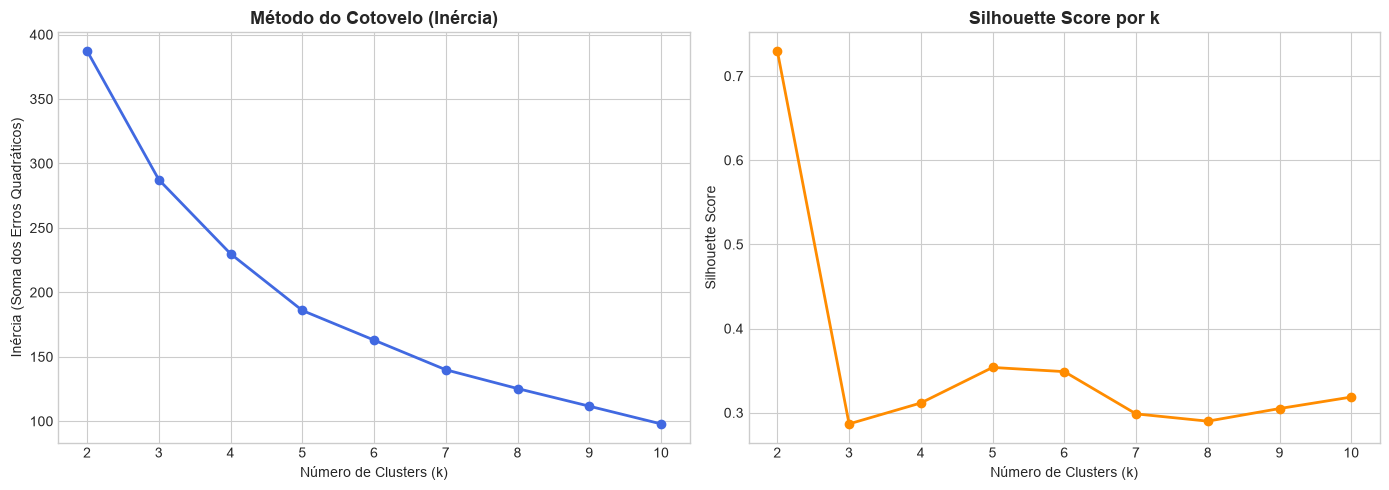

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Gráfico 1: Método do Cotovelo
ax1.plot(k_range, inertias, marker='o', color='royalblue', linewidth=2)
ax1.set_title('Método do Cotovelo (Inércia)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia (Soma dos Erros Quadráticos)')
ax1.set_xticks(k_range)

ax2.plot(k_range, silhouettes, marker='o', color='darkorange', linewidth=2)
ax2.set_title('Silhouette Score por k', fontsize=13, fontweight='bold')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range)
plt.tight_layout()

In [10]:
k_escolhido = 5
kmeans_final = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
df_ml['CLUSTER'] = kmeans_final.fit_predict(X_scaled)

# 2. Ver a contagem de registros em cada cluster
print("Distribuição das empresas por Cluster:")
print(df_ml['CLUSTER'].value_counts().sort_index())

# 3. Analisar a MÉDIA real de cada cluster (em valores reais, não padronizados!)
resumo_clusters = df_ml.groupby('CLUSTER')[features].mean().round(2)
resumo_clusters

Distribuição das empresas por Cluster:
CLUSTER
0    49
1    14
2    51
3     6
4    44
Name: count, dtype: int64


c:\Users\Guilherme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,RETORNO_ANO_%
CLUSTER,,,,
0,1.66,24.23,0.08,-25.75
1,50.33,161.62,0.30,17.18
2,5.38,20.68,0.28,46.71
3,424.93,320.84,1.41,27.98
4,26.30,35.31,0.79,10.28


<Axes: xlabel='LUCRO_LIQUIDO_BI', ylabel='PATRIMONIO_LIQUIDO_BI'>

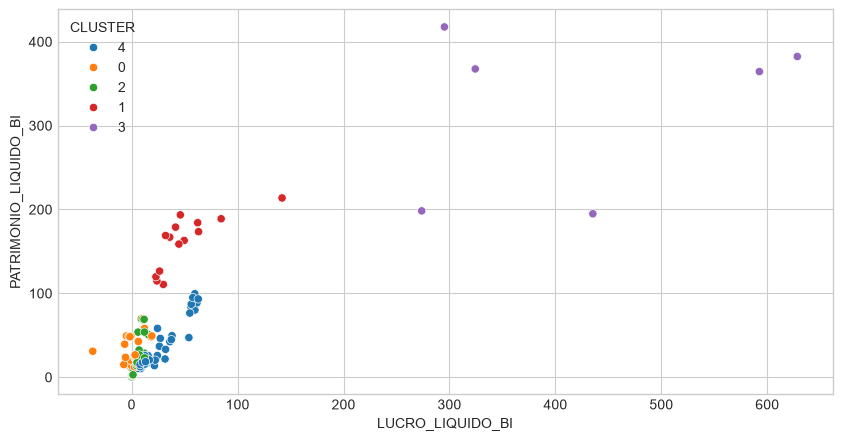

In [11]:
plt.figure(figsize=(10,5))
sns.scatterplot(df_ml,x='LUCRO_LIQUIDO_BI',y='PATRIMONIO_LIQUIDO_BI',hue=df_ml['CLUSTER'].astype(str))

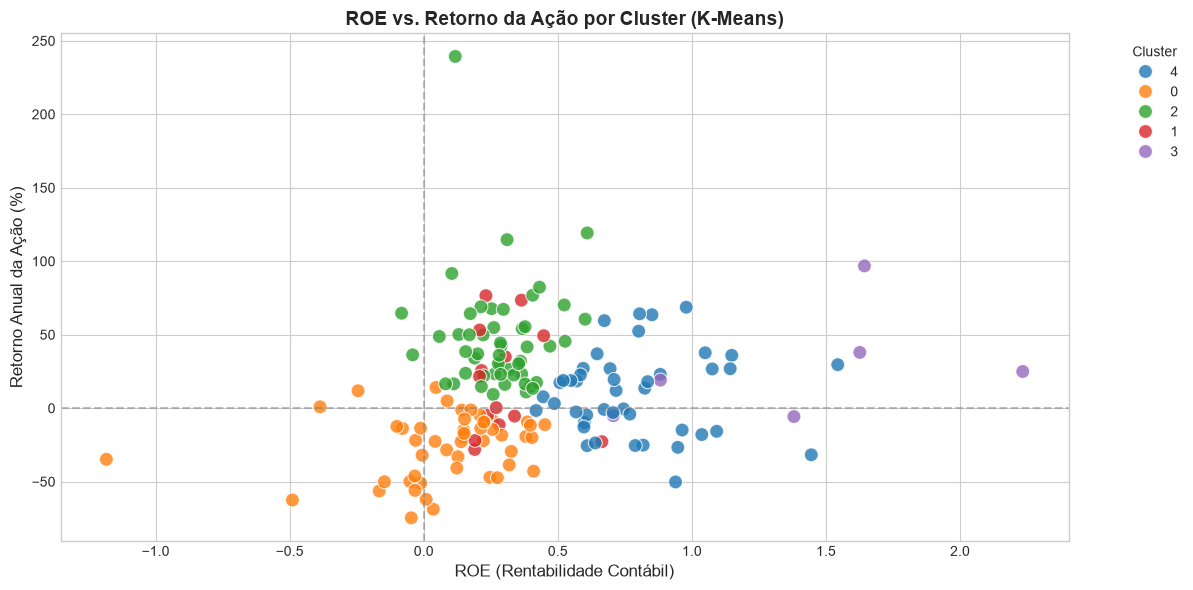

In [12]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df_ml, 
    x='ROE', 
    y='RETORNO_ANO_%', 
    hue=df_ml['CLUSTER'].astype(str), 
    palette='tab10',
    s=100, 
    alpha=0.8
)

plt.title('ROE vs. Retorno da Ação por Cluster (K-Means)', fontsize=14, fontweight='bold')
plt.xlabel('ROE (Rentabilidade Contábil)', fontsize=12)
plt.ylabel('Retorno Anual da Ação (%)', fontsize=12)
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [13]:
df_ml[df_ml['CLUSTER'] == 0][['EMPRESA', 'ANO', 'ROE', 'RETORNO_ANO_%']].head(10)

,EMPRESA,ANO,ROE,RETORNO_ANO_%
6,BR MALLS PARTICIPACOES S.A.,2022,0.149222,-19.964812
13,ALUPAR INVESTIMENTO S/A,2024,0.256825,-8.457766
17,AUREN ENERGIA S.A.,2024,-0.006327,-31.992731
36,BRAVA ENERGIA S.A.,2025,0.085192,-28.401360
49,COGNA EDUCAÇÃO S.A.,2022,-0.079598,-13.821145
51,COGNA EDUCAÇÃO S.A.,2024,0.035458,-68.767911
59,COSAN S.A.,2022,0.380808,-19.264716
61,COSAN S.A.,2024,-0.166353,-56.367893
62,COSAN S.A.,2025,-1.183901,-34.803918
66,CIA SIDERURGICA NACIONAL,2024,-0.146903,-50.087421


In [14]:
bancos = ['BBDC4.SA', 'SANB11.SA', 'BBAS3.SA']
df_ml[df_ml['TICKER'].isin(bancos)][['ANO', 'TICKER', 'ROE', 'RETORNO_ANO_%', 'CLUSTER']].sort_values(by=['TICKER', 'ANO'])

,ANO,TICKER,ROE,RETORNO_ANO_%,CLUSTER
25,2022,BBAS3.SA,0.303980,34.956895,1
26,2023,BBAS3.SA,0.363926,73.492608,1
27,2024,BBAS3.SA,0.338354,-5.409092,1
28,2025,BBAS3.SA,0.237403,-4.939482,1
30,2022,BBDC4.SA,0.280948,-11.298492,1
31,2023,BBDC4.SA,0.215308,25.624641,1
32,2024,BBDC4.SA,0.189679,-28.121029,1
33,2025,BBDC4.SA,0.231725,76.541612,1
163,2022,SANB11.SA,0.270137,0.351251,1
164,2023,SANB11.SA,0.207549,21.616176,1


In [15]:
#Agora vamos separar as empresas por cluster, anteriormente eu separei o ano dela, pra ver as tendências delas conforme os anos foram passando
#agora vou ver um geral dela nesses 5 anos 

df_empresa = df_ml.groupby(['TICKER', 'EMPRESA', 'SETOR']).agg({
    'LUCRO_LIQUIDO_BI': 'mean',
    'PATRIMONIO_LIQUIDO_BI': 'mean',
    'ROE': 'mean',
    'RETORNO_ANO_%': 'mean'
}).reset_index()

In [16]:
df_empresa.head()

,TICKER,EMPRESA,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,RETORNO_ANO_%
0,ABEV3.SA,AMBEV S.A.,Bebidas e Fumo,59.254210,87.956731,0.677670,3.935803
1,ALOS3.SA,ALLOS S.A.,Emp. Adm. Part. - Comércio (Atacado e Varejo),6.063159,14.016763,0.431068,21.061587
2,ALOS3.SA,BR MALLS PARTICIPACOES S.A.,Emp. Adm. Part. - Comércio (Atacado e Varejo),4.791264,12.198872,0.375454,20.295186
3,ALUP11.SA,ALUPAR INVESTIMENTO S/A,Emp. Adm. Part. - Energia Elétrica,3.301385,11.325107,0.293115,17.102922
4,AURE3.SA,AUREN ENERGIA S.A.,Energia Elétrica,1.352733,13.542590,0.111300,5.095593


In [17]:
df_empresa = df_ml.groupby('TICKER').agg({
    'EMPRESA': 'last',        
    'SETOR': 'last',          
    'LUCRO_LIQUIDO_BI': 'mean',
    'PATRIMONIO_LIQUIDO_BI': 'mean',
    'ROE': 'mean',
    'RETORNO_ANO_%': 'mean'
}).reset_index()

df_empresa.head()

,TICKER,EMPRESA,SETOR,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,RETORNO_ANO_%
0,ABEV3.SA,AMBEV S.A.,Bebidas e Fumo,59.254210,87.956731,0.677670,3.935803
1,ALOS3.SA,ALLOS S.A.,Emp. Adm. Part. - Comércio (Atacado e Varejo),5.427212,13.107817,0.403261,20.678387
2,ALUP11.SA,ALUPAR INVESTIMENTO S/A,Emp. Adm. Part. - Energia Elétrica,3.301385,11.325107,0.293115,17.102922
3,AURE3.SA,AUREN ENERGIA S.A.,Energia Elétrica,1.352733,13.542590,0.111300,5.095593
4,B3SA3.SA,"B3 S.A. - BRASIL, BOLSA, BALCÃO",Bolsas de Valores/Mercadorias e Futuros,17.587781,19.104194,0.925732,11.892028


In [18]:
# 1. Selecionar as features da base consolidada por empresa
features = ['LUCRO_LIQUIDO_BI', 'PATRIMONIO_LIQUIDO_BI', 'ROE', 'RETORNO_ANO_%']
X_empresa = df_empresa[features]

# 2. Re-escalonar com StandardScaler
scaler_empresa = StandardScaler()
X_empresa_scaled = scaler_empresa.fit_transform(X_empresa)



In [19]:
# 2. Calcular Inércia e Silhouette para k de 2 a 10
k_range = range(2, 11)
inertias_emp = []
silhouettes_emp = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_empresa_scaled)
    inertias_emp.append(km.inertia_)
    silhouettes_emp.append(silhouette_score(X_empresa_scaled, km.labels_))

c:\Users\Guilherme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Guilherme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Guilherme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Guilherme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memor

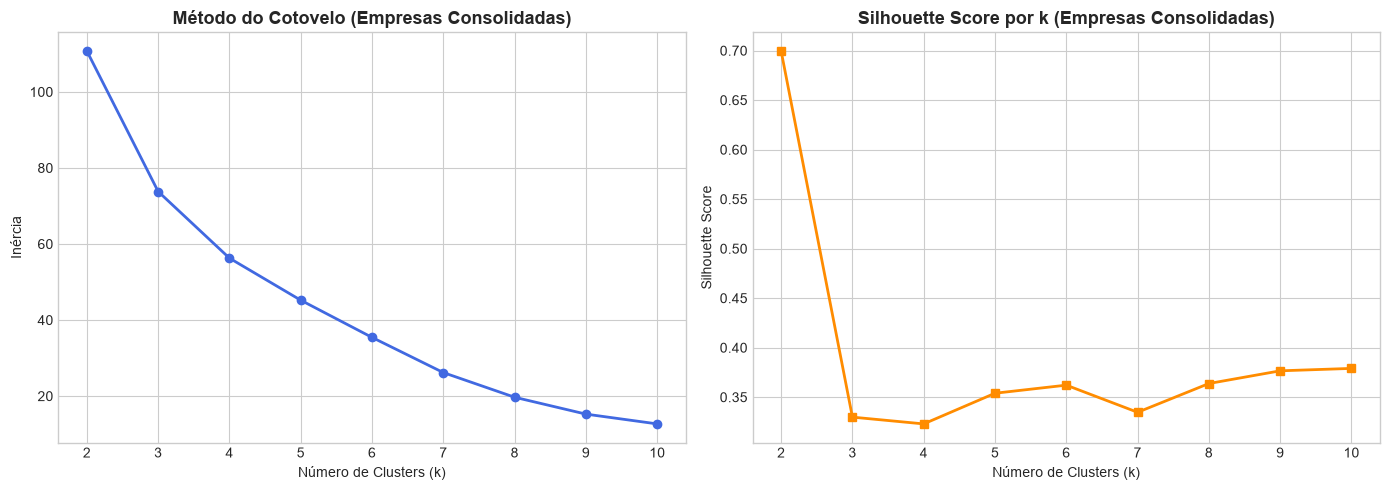

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Gráfico 1: Cotovelo
ax1.plot(k_range, inertias_emp, marker='o', color='royalblue', linewidth=2)
ax1.set_title('Método do Cotovelo (Empresas Consolidadas)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia')
ax1.set_xticks(k_range)
# Gráfico 2: Silhouette Score
ax2.plot(k_range, silhouettes_emp, marker='s', color='darkorange', linewidth=2)
ax2.set_title('Silhouette Score por k (Empresas Consolidadas)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range)
plt.tight_layout()

In [21]:
# 1. Treinar o K-Means definitivo com k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_empresa['CLUSTER'] = kmeans_final.fit_predict(X_empresa_scaled)

# 2. Quantidade de empresas em cada grupo
print("=== DISTRIBUIÇÃO DAS EMPRESAS POR CLUSTER ===")
print(df_empresa['CLUSTER'].value_counts().sort_index())

# 3. Média das variáveis por Cluster (em valores reais)
resumo_empresa = df_empresa.groupby('CLUSTER')[features].mean().round(2)
print("\n=== PERFIL MÉDIO DOS CLUSTERS ===")
resumo_empresa

=== DISTRIBUIÇÃO DAS EMPRESAS POR CLUSTER ===
CLUSTER
0    23
1     2
2    12
3    11
Name: count, dtype: int64

=== PERFIL MÉDIO DOS CLUSTERS ===


c:\Users\Guilherme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,LUCRO_LIQUIDO_BI,PATRIMONIO_LIQUIDO_BI,ROE,RETORNO_ANO_%
CLUSTER,,,,
0,9.70,37.82,0.27,22.73
1,347.01,290.96,1.20,24.30
2,25.82,36.05,0.79,17.07
3,1.73,20.75,0.11,-19.12


In [22]:
def empresas_k(c):
    print(f"\n--- CLUSTER {c} (Total: {sum(df_empresa['CLUSTER'] == c)}) ---")
    print(df_empresa[df_empresa['CLUSTER'] == c][['TICKER', 'EMPRESA', 'ROE', 'RETORNO_ANO_%']].to_string(index=False))

In [23]:
empresas_k(0)


--- CLUSTER 0 (Total: 23) ---
   TICKER                                  EMPRESA       ROE  RETORNO_ANO_%
 ALOS3.SA                               ALLOS S.A.  0.403261      20.678387
ALUP11.SA                  ALUPAR INVESTIMENTO S/A  0.293115      17.102922
 AURE3.SA                       AUREN ENERGIA S.A.  0.111300       5.095593
 BBAS3.SA                          BCO BRASIL S.A.  0.310916      24.525232
 BBDC4.SA                        BCO BRADESCO S.A.  0.229415      15.686683
 BRSR6.SA  BANCO DO ESTADO DO RIO GRANDE DO SUL SA  0.213024      68.975719
 CMIG4.SA   CIA ENERGETICA DE MINAS GERAIS - CEMIG  0.412826      26.688902
 COGN3.SA                      COGNA EDUCAÇÃO S.A. -0.002426      55.350551
 CXSE3.SA      CAIXA SEGURIDADE PARTICIPAÇÕES S.A.  0.533404      30.894733
 ENEV3.SA                                ENEVA S.A  0.064118      27.698218
ENGI11.SA                            ENERGISA S.A.  0.337339      16.988636
 EQTL3.SA                          EQUATORIAL S.A.  0.242

In [24]:
empresas_k(1)


--- CLUSTER 1 (Total: 2) ---
  TICKER                            EMPRESA     ROE  RETORNO_ANO_%
PETR4.SA PETROLEO BRASILEIRO S.A. PETROBRAS 1.21477      37.168679
VALE3.SA                          VALE S.A. 1.18144      11.429546


In [25]:
empresas_k(2)


--- CLUSTER 2 (Total: 12) ---
  TICKER                             EMPRESA      ROE  RETORNO_ANO_%
ABEV3.SA                          AMBEV S.A. 0.677670       3.935803
B3SA3.SA     B3 S.A. - BRASIL, BOLSA, BALCÃO 0.925732      11.892028
CMIN3.SA                  CSN MINERAÇÃO S.A. 0.738628      22.873784
CPFE3.SA                   CPFL ENERGIA S.A. 1.059974      28.331237
EGIE3.SA           ENGIE BRASIL ENERGIA S.A. 1.543878      29.596094
GOAU4.SA             METALURGICA GERDAU S.A. 0.638367      10.788354
ITSA4.SA                         ITAÚSA S.A. 0.661138      25.979001
PRIO3.SA                           PRIO S.A. 0.542059      -4.824513
SBSP3.SA CIA SANEAMENTO BASICO EST SAO PAULO 0.780326      41.530475
SUZB3.SA                 SUZANO HOLDING S.A. 0.540565       0.723852
VBBR3.SA                   VIBRA ENERGIA S/A 0.834515      19.295699
WEGE3.SA                            WEG S.A. 0.580196      14.685825


In [26]:
empresas_k(3)


--- CLUSTER 3 (Total: 11) ---
  TICKER                                    EMPRESA       ROE  RETORNO_ANO_%
BRAV3.SA                         BRAVA ENERGIA S.A.  0.085192     -28.401360
CSAN3.SA                                 COSAN S.A. -0.166788     -23.569855
CSNA3.SA                   CIA SIDERURGICA NACIONAL  0.293094      -6.517562
HAPV3.SA HAPVIDA PARTICIPAÇÕES E INVESTIMENTOS S.A. -0.049141     -42.328267
HYPE3.SA                                HYPERA S.A.  0.246137      -9.499139
LREN3.SA                          LOJAS RENNER S.A.  0.454182      -4.609155
MGLU3.SA                        MAGAZINE LUIZA S.A.  0.006561     -29.309055
PCAR3.SA             CIA BRASILEIRA DE DISTRIBUICAO  0.139227     -22.835702
RAIL3.SA                                  RUMO S.A.  0.050063      -1.734105
RAIZ4.SA                        RAIZEN ENERGIA S.A. -0.147387     -30.699748
USIM5.SA   USINAS SID DE MINAS GERAIS S.A.-USIMINAS  0.274511     -10.776812


In [27]:
# 1. Mapear os novos nomes de negócio
nomes_clusters = {
    0: "Cluster 0: Blue Chips & Sólidas (+23% a.a.)",
    1: "Cluster 1: Titãs da Bolsa (PETR4 / VALE3)",
    2: "Cluster 2: Campeãs de Super ROE (+17% a.a.)",
    3: "Cluster 3: Em Queda / Varejo e Dívida (-19% a.a.)"
}
df_empresa['PERFIL'] = df_empresa['CLUSTER'].map(nomes_clusters)


<Axes: xlabel='ROE', ylabel='RETORNO_ANO_%'>

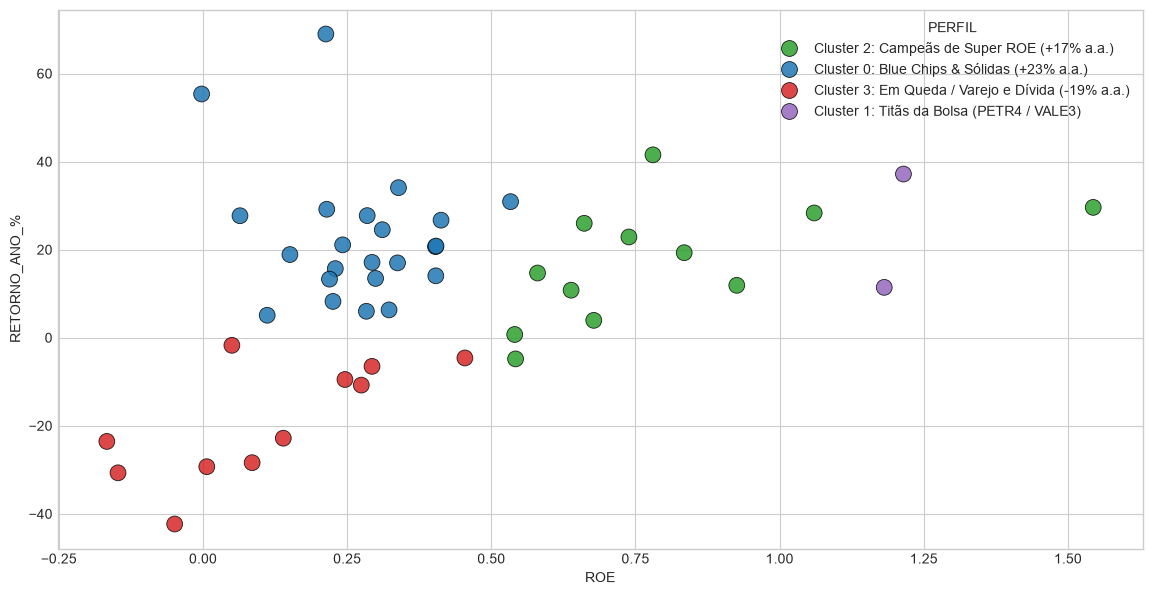

In [28]:
plt.figure(figsize=(14, 7))
cores = {
    "Cluster 0: Blue Chips & Sólidas (+23% a.a.)": "#1f77b4",       # Azul
    "Cluster 1: Titãs da Bolsa (PETR4 / VALE3)": "#9467bd",         # Roxo
    "Cluster 2: Campeãs de Super ROE (+17% a.a.)": "#2ca02c",       # Verde
    "Cluster 3: Em Queda / Varejo e Dívida (-19% a.a.)": "#d62728"  # Vermelho
}
sns.scatterplot(
    data=df_empresa,
    x='ROE',
    y='RETORNO_ANO_%',
    hue='PERFIL',
    palette=cores,
    s=130,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.6
)

In [29]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [30]:
import plotly.express as px

# Criando o gráfico de dispersão interativo
fig = px.scatter(
    df_empresa,
    x='ROE',
    y='RETORNO_ANO_%',
    color='PERFIL',
    hover_name='EMPRESA',                    # Nome que aparece em destaque no topo ao passar o mouse
    hover_data={
        'TICKER': True,
        'ROE': ':.2f',
        'RETORNO_ANO_%': ':.2f',
        'LUCRO_LIQUIDO_BI': ':.2f',
        'PATRIMONIO_LIQUIDO_BI': ':.2f',
        'PERFIL': False                      # Já está na cor/legenda
    },
    title='<b>Mapa Interativo dos Perfis da B3 (Passe o mouse sobre os pontos!)</b>',
    labels={
        'ROE': 'ROE Médio (2022-2025)',
        'RETORNO_ANO_%': 'Retorno Médio Anual (%)',
        'PERFIL': 'Perfil / Cluster'
    },
    template='plotly_white',
    height=650
)

# Linhas de referência (zero a zero)
fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.6)
fig.add_vline(x=0, line_dash="dash", line_color="gray", opacity=0.6)

# Atualizar o tamanho das bolinhas
fig.update_traces(marker=dict(size=12, opacity=0.85, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

In [31]:
df_empresa[['TICKER', 'CLUSTER', 'PERFIL']].to_csv(r'..\data\processed\clusters_empresas.csv', index=False)